In [1]:
import torch
import os
import sys

import numpy as np
from src.colour_mnist import get_biased_mnist_dataloader
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
from craft.craft_torch import Craft, torch_to_numpy


import matplotlib.pyplot as plt
import random as rd
import pickle as pkl

2025-09-10 14:35:11.834801: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-10 14:35:11.866391: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

2025-09-10 14:35:12.587067: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
sys.path.append(os.getcwd())
sys.path

['/home/thomas/.conda/envs/debiafting/lib/python313.zip',
 '/home/thomas/.conda/envs/debiafting/lib/python3.13',
 '/home/thomas/.conda/envs/debiafting/lib/python3.13/lib-dynload',
 '',
 '/home/thomas/.conda/envs/debiafting/lib/python3.13/site-packages',
 '/tmp/tmpk6a7mpoq',
 '/home/thomas/Documents/ENS/IAS/S2/XCL/CVDB']

In [4]:
exp_id = 0
exp_name = "MNIST"
with open("models/" + exp_name + "/model_" + str(exp_id) + ".pkl", "rb") as f:
    res = pkl.load(f)
res

{'model_id': 0,
 'model_name': 'MNIST',
 'batch_size': 256,
 'train_correlation': 0.7,
 'test_correlation': 0.1,
 'epochs': 20,
 'correctness_matrix': array([[ 98,  98,  96,  96,  90,  93,  95,  93,  97,  96],
        [110, 113, 114, 113, 111,  85, 114, 113, 112, 114],
        [101, 102, 100,  94,  96,  96, 103, 100,  96,  91],
        [ 97,  97,  92, 101,  87,  65,  95,  88,  84,  94],
        [ 79,  88,  97,  93,  98,  92,  97,  98,  98,  94],
        [ 84,  84,  85,  85,  89,  88,  88,  85,  80,  85],
        [ 94,  94,  92,  93,  87,  79,  95,  96,  93,  94],
        [100,  98,  92,  96,  93,  94, 101, 102,  92,  94],
        [ 81,  95,  94,  82,  84,  94,  91,  79,  95,  92],
        [ 95,  84,  98,  91,  50,  92,  95,  88,  95, 100]]),
 'appearance_matrix': array([[ 98,  98,  98,  98,  98,  98,  98,  98,  98,  98],
        [110, 113, 114, 114, 114, 114, 114, 114, 114, 114],
        [104, 104, 103, 104, 104, 104, 104, 104, 104,  97],
        [101, 101, 101, 101, 101, 101, 101, 101

In [17]:
data_path = os.getcwd() + "/data/MNIST"
device = "cuda"
test_dataloader = get_biased_mnist_dataloader(root=data_path, batch_size=res["batch_size"], data_label_correlation=res["test_correlation"], train=False)
# Define model
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.l1 = nn.Sequential(nn.Linear(28*28*3, 512), nn.ReLU())
        self.l2 = nn.Sequential(nn.Linear(512, 512), nn.ReLU())
        self.l3 = nn.Sequential(nn.Linear(512, 10))

    def forward(self, x):
        x = self.flatten(x)
        x = self.l1(x)
        x = self.l2(x)
        logits = self.l3(x)
        return logits

model = NeuralNetwork().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    appearance_matrix = []
    correctness_matrix = None
    with torch.no_grad():
        for X, y, y_pred in dataloader:
            X, y, y_pred = X.to(device), y.to(device), y_pred.to(device)
            pred = model(X)
            if len(appearance_matrix)==0:
                size_y = len(pred[0])
                appearance_matrix = np.array([[0 for i in range(size_y)] for j in range(size_y)])
                correctness_matrix = np.array([[0 for i in range(size_y)] for j in range(size_y)])
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
            for i in range(size_y):
                for j in range(size_y):
                    appearance_matrix[i][j] += int(((y==i) & (y_pred==j)).sum())
                    correctness_matrix[i][j] += int((pred.argmax(1)[((y==i) & (y_pred==j))] == i).sum())
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")
    accuracy_matrix = correctness_matrix/appearance_matrix
    return accuracy_matrix

assert(os.path.exists(f"models/{exp_name}/model_{exp_id}"))
model.load_state_dict(torch.load(f"models/{exp_name}/model_{exp_id}", weights_only=True))

base_acc = test(test_dataloader, model, loss_fn)

Test Error: 
 Accuracy: 78.1%, Avg loss: 0.659705 



In [19]:
import seaborn as sb

<Axes: >

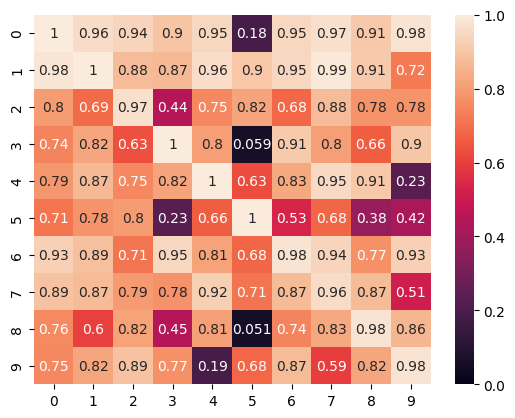

In [21]:
sb.heatmap(base_acc, vmin=0, vmax=1, annot=True)

<Axes: >

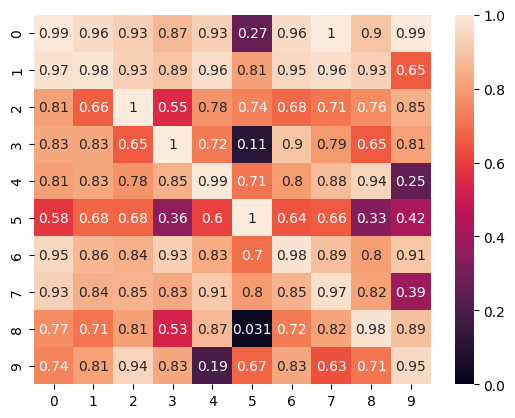

In [20]:
sb.heatmap(res["accuracy_matrix"], vmin=0, vmax=1, annot=True)